In [3]:
#%pip install scipy
%pip install tensorflow
#%pip install pandas
#%pip install seaborn
#%pip install numpy
#%pip install scikit-learn
#%pip install matplotlib

In [4]:
#Imports

import pandas as pd
import seaborn
import numpy as np
import matplotlib.pyplot as plt

#imports for transformed model
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

#tensorflow imports for transformer model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import TextVectorization, Embedding, Dense, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Dropout, Concatenate

In [6]:
#Data Parsing

#Open and read the dataset file
with open("dataset_", "r") as f:
    lines = f.readlines()

#Skip to where the data actually starts in the file
data_start = next(i for i, line in enumerate(lines) if "@DATA" in line)

#From here parse the dataset into a usable dataset
dataset = pd.read_csv("dataset_", skiprows=data_start+1, header=None)

#Get the feature column
dataset.columns = ['id','rated','created_at','last_move_at','turns','victory_status','winner','increment_code','white_id','white_rating','black_id','black_rating','moves','opening_eco','opening_name','opening_ply']

#Look at the dataset before preprocessing
dataset.head()



,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,'2017-08-31 20:06:40','2017-08-31 20:06:40',13,outoftime,white,15+2,bourgris,1500,a-00,1191,'d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba...,D10,'Slav Defense: Exchange Variation',5
1,l1NXvwaE,True,'2017-08-30 21:53:20','2017-08-30 21:53:20',16,resign,black,5+10,a-00,1322,skinnerua,1261,'d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc...,B00,'Nimzowitsch Defense: Kennedy Variation',4
2,mIICvQHh,True,'2017-08-30 21:53:20','2017-08-30 21:53:20',61,mate,white,5+10,ischia,1496,a-00,1500,'e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 N...,C20,'King\'s Pawn Game: Leonardis Variation',3
3,kWKvrqYL,True,'2017-08-30 16:20:00','2017-08-30 16:20:00',61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,'d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 ...,D02,'Queen\'s Pawn Game: Zukertort Variation',3
4,9tXo1AUZ,True,'2017-08-29 18:06:40','2017-08-29 18:06:40',95,mate,white,30+3,nik221107,1523,adivanov2009,1469,'e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 ...,C41,'Philidor Defense',5


In [8]:
#Data Preprocessing

# Additional Feature Extraction, Some additional features can be extracted to provide relevent data

#rating_diff: the difference in rating between players
#base_time: the base time amount set for the game
#time_increment: the time gained per move
#opening_strategy: Strategy of opening correlating to eco code letter (A, B, C, D, E)

dataset["rating_diff"] = dataset["white_rating"] - dataset["black_rating"]
dataset[["base_time", "time_increment"]] = dataset["increment_code"].str.split("+", expand=True)
dataset["opening_strategy"] = dataset["opening_eco"].str[0]


#Feature Refinement (Convert features to values that can be used in analysis)

#Convert boolean to integers
dataset["rated"] = dataset["rated"].astype(str).str.lower().map({"true": 1, "false": 0})

#Convert time to integers
dataset["base_time"] = dataset["base_time"].astype(int)
dataset["time_increment"] = dataset["time_increment"].astype(int)

#Get unique values of opening code and victory type
opening_strategy_values = dataset["opening_strategy"].unique()
winner_values = dataset["winner"].unique()
victory_status_values = dataset["victory_status"].unique()


#Data encoding (Encode non-numeric feature data into representative values that can be used for anlaysis)

#Create encoder to convert string data to binary array data
encoder = OneHotEncoder(categories=[opening_strategy_values, winner_values, victory_status_values], handle_unknown="ignore", sparse_output=False)

#Encode the data to unique values
encoded_Data = encoder.fit_transform(dataset[["opening_strategy", "winner", "victory_status"]])

#Create a dataframe from the encoded data to be appended to the dataset
encoded_dataframe = pd.DataFrame(encoded_Data, columns=encoder.get_feature_names_out(["opening_strategy", "winner", "victory_status"]), index = dataset.index)

#Append the encoded data to the dataset
dataset = pd.concat([dataset, encoded_dataframe], axis=1)



dataset.head()

['white' 'black' 'draw']


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,...,opening_strategy_C,opening_strategy_A,opening_strategy_E,winner_white,winner_black,winner_draw,victory_status_outoftime,victory_status_resign,victory_status_mate,victory_status_draw
0,TZJHLljE,NaN,'2017-08-31 20:06:40','2017-08-31 20:06:40',13,outoftime,white,15+2,bourgris,1500,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,l1NXvwaE,NaN,'2017-08-30 21:53:20','2017-08-30 21:53:20',16,resign,black,5+10,a-00,1322,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,mIICvQHh,NaN,'2017-08-30 21:53:20','2017-08-30 21:53:20',61,mate,white,5+10,ischia,1496,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,kWKvrqYL,NaN,'2017-08-30 16:20:00','2017-08-30 16:20:00',61,mate,white,20+0,daniamurashov,1439,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,9tXo1AUZ,NaN,'2017-08-29 18:06:40','2017-08-29 18:06:40',95,mate,white,30+3,nik221107,1523,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


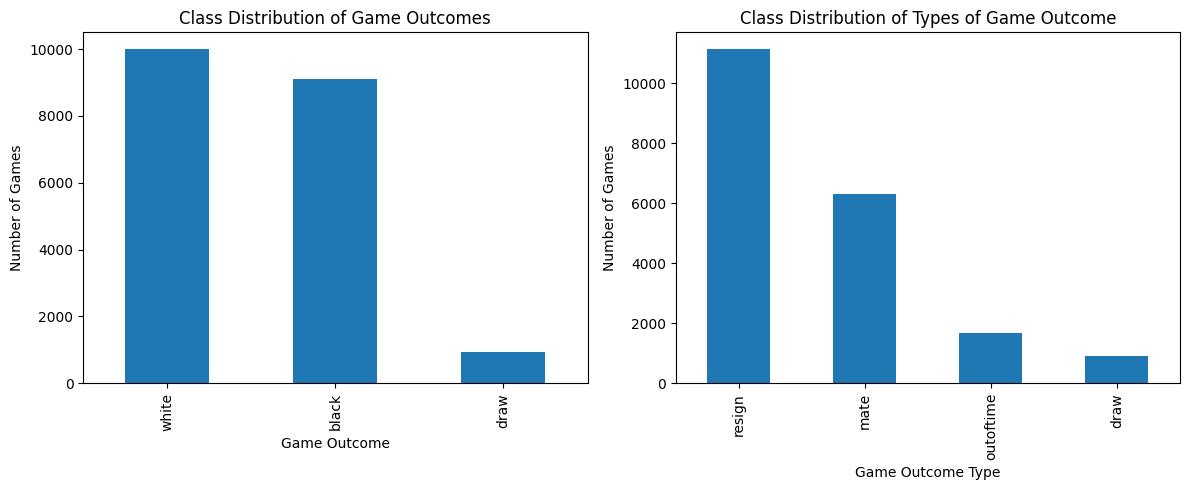

In [9]:
# get the number of each game outcome
winner_class_counts = dataset["winner"].value_counts()

# get the number of each victory type
type_winner_class_counts = dataset["victory_status"].value_counts()

# create two plots in one figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# plot winner distribution
winner_class_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Class Distribution of Game Outcomes")
axes[0].set_xlabel("Game Outcome")
axes[0].set_ylabel("Number of Games")

# plot victory type distribution
type_winner_class_counts.plot(kind="bar", ax=axes[1])
axes[1].set_title("Class Distribution of Types of Game Outcome")
axes[1].set_xlabel("Game Outcome Type")
axes[1].set_ylabel("Number of Games")

plt.tight_layout()
plt.show()

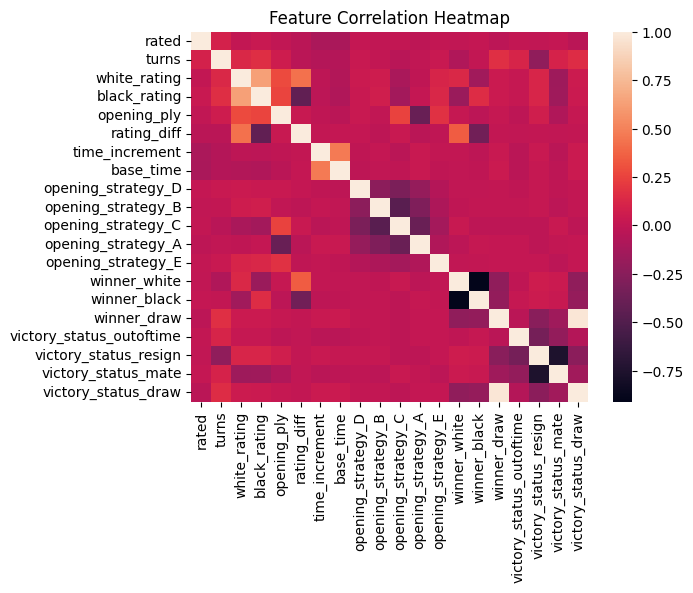

In [ ]:
#use only the numeric features
numeric_features = dataset[["rated", "turns", "white_rating", "black_rating", "opening_ply", "rating_diff", "time_increment", "base_time"] + list(encoded_dataframe.columns)]

#Create a correlation matrix
corr_matrix = numeric_features.corr()

# Plot feature heatmap
plt.figure()
seaborn.heatmap(corr_matrix)

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:

#Create training data for Random Forest Model
rf_dataset = dataset.copy()

#Add desired features to be used -
features = ["rated", "turns", "white_rating", "black_rating", "opening_ply", "rating_diff", "base_time", "time_increment"]

#Add encoded opening strategy
opening_cols = [col for col in rf_dataset.columns if "opening_strategy_" in col]

#Create the total features to be used
x = rf_dataset[features + opening_cols]

#Define what we are trying to predict
y_winner = rf_dataset["winner"]
y_status = rf_dataset["victory_status"]

#Create the training and testing data
x_train, x_test, y_winner_train, y_winner_test, y_status_train, y_status_test = train_test_split( x, y_winner, y_status,
    test_size=0.2, random_state=42, stratify=y_winner)



In [ ]:
rf_estimators = 250

#Define estimators number here to allow for easy manipulation if necesary
param_distributions = {
    'n_estimators': [100, 200, 300, 400],           # Number of trees
    'max_depth': [None, 10, 20, 30, 40],            # Max depth of the trees
    'min_samples_split': [2, 5, 10],                # Minimum samples needed to split a node
    'min_samples_leaf': [1, 2, 4],                  # Minimum samples needed at a leaf node
    'max_features': ['sqrt', 'log2', None]          # Number of features to consider at every split
}

#Define Random Forest Classifier for determineing the Winner and the Victory Status
rf_winner_base = RandomForestClassifier(random_state=42, class_weight="balanced")
rf_status = RandomForestClassifier(n_estimators=rf_estimators, random_state=42, class_weight="balanced")


# 3. Set up the Randomized Search

winner_search = RandomizedSearchCV(
    estimator=rf_winner_base,
    param_distributions=param_distributions,
    n_iter=15,
    cv=5,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1,
    verbose=1 # Prints progress to the console
)

print("\nOptimizing Winner Model...")
winner_search.fit(x_train, y_winner_train)
print("Best parameters for Winner Model:", winner_search.best_params_)


# Victory status model CV
status_f1_scores = cross_val_score(rf_status, x_train, y_status_train, cv=5, scoring="f1_weighted")

print("\nStatus weighted F1 scores:", status_f1_scores)
print("Status Mean weighted F1:", status_f1_scores.mean())

#Train models
rf_winner_best = winner_search.best_estimator_
rf_status.fit(x_train, y_status_train)


#test models
y_winner_pred = rf_winner_best.predict(x_test)
y_status_pred = rf_status.predict(x_test)


# Winner metrics
winner_accuracy = accuracy_score(y_winner_test, y_winner_pred)
winner_precision = precision_score(y_winner_test, y_winner_pred, average="weighted", zero_division=0)
winner_recall = recall_score(y_winner_test, y_winner_pred, average="weighted", zero_division=0)

# Status metrics
status_accuracy = accuracy_score(y_status_test, y_status_pred)
status_precision = precision_score(y_status_test, y_status_pred, average="weighted")
status_recall = recall_score(y_status_test, y_status_pred, average="weighted")

#Model Performance
print("\n--- Optimized Winner Model Performance ---")
print("Accuracy:", winner_accuracy)
print("Precision (weighted):", winner_precision)
print("Recall (weighted):", winner_recall)

print("\nVictory Status Model")
print("Accuracy:", status_accuracy)
print("Precision (weighted):", status_precision)
print("Recall (weighted):", status_recall)


Optimizing Winner Model...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters for Winner Model: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 30}

Status weighted F1 scores: [0.55532963 0.5617043  0.55824229 0.5470285  0.54359804]
Status Mean weighted F1: 0.5531805517017366

--- Optimized Winner Model Performance ---
Accuracy: 0.7116151545363908
Precision (weighted): 0.7026864412966741
Recall (weighted): 0.7116151545363908

Victory Status Model
Accuracy: 0.6021934197407777
Precision (weighted): 0.596264813494583
Recall (weighted): 0.6021934197407777


In [ ]:
#Copy dataset for transformer model
transformer_dataset = dataset.copy()

#Clean moves for transformer analysis
cleaned_moves = []

#

# Iterate through all the moves strings
for move_string in transformer_dataset["moves"]:

    #Get the string, unnecessary whitespace and quotes from at beginning and end
    move_string = str(move_string).strip().strip("'")

    # If last character is '#', remove last move
    if move_string[-1] == "#":
        last_space = move_string.rfind(" ")
        move_string = move_string[:last_space]

    cleaned_moves.append(move_string)

# Add cleaned column
transformer_dataset["moves_clean"] = cleaned_moves

#There are ~28000 possible chess notations barring checkmates leading to 30000 max tokens for safety
max_tokens = 30000

#The max moves is 349, 350 for safety
sequence_length = 350

vectorizer = TextVectorization(max_tokens=max_tokens, output_mode="int", output_sequence_length=sequence_length,
    standardize=None, split="whitespace")

# Adapt on cleaned moves
move_text = transformer_dataset["moves_clean"].astype(str).values
vectorizer.adapt(move_text)

vocab_size = len(vectorizer.get_vocabulary())

# Convert to vectors
move_vectors = vectorizer(move_text).numpy()

# Check vector shape
print("\nVector shape:", move_vectors.shape)

#Look at first cleaned moves
print("\nFirst cleaned move string:")
print(transformer_dataset.loc[0, "moves_clean"])

#Look at first token vector
print("\nFirst token vector:")
print(move_vectors[0])

#Look at first 30 tokens
print("\nFirst 30 vocabulary tokens:")
print(vectorizer.get_vocabulary()[:30])

#Check unknown index value, should be 0
unk_index = 1
num_unk = np.sum(move_vectors == unk_index)
print("Total [UNK] tokens in all vectors:", num_unk)


# Numeric features to include
numeric_cols = ["white_rating", "black_rating", "rating_diff", "base_time", "time_increment"]

# Make sure numeric features are numeric
X_numeric = transformer_dataset[numeric_cols].astype(float).values

# One-hot encode opening_eco
opening_onehot = pd.get_dummies(transformer_dataset["opening_eco"], prefix="eco")

# Convert opening encoding to numpy
X_opening = opening_onehot.values

# Combine numeric + opening encoding into one extra feature matrix
extra_features = np.hstack([X_numeric, X_opening])






Vector shape: (20058, 350)

First cleaned move string:
d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5 Bf4

First token vector:
[  6   9  12  24  69  13 472 218   3 225  10 344  57   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 

In [ ]:

#Encode Winner and Status Labels
winner_encoder = LabelEncoder()
status_encoder = LabelEncoder()

y_winner = winner_encoder.fit_transform(transformer_dataset["winner"])
y_status = status_encoder.fit_transform(transformer_dataset["victory_status"])

#Check Labels
n_winner_classes = len(winner_encoder.classes_)
n_status_classes = len(status_encoder.classes_)

print("Winner classes :", list(winner_encoder.classes_))
print("Status classes :", list(status_encoder.classes_))

# Split the Data into Training Data (things with _train) and Testing Data (things with _test).
# Uses both the moves list vectorized token and numeric features like: white_rating, time_increment, etc.
# X_moves_: move list training/testing data
# X_extra_: numeric features training/testing data
# y_winner_: y_winner training and testing data
# y_status_: y_status trainging/testing data

X_moves_train, X_moves_test, X_extra_train, X_extra_test, y_winner_train, y_winner_test, y_status_train, y_status_test = train_test_split(
    move_vectors,
    extra_features,
    y_winner,
    y_status,
    test_size=0.2,
    random_state=42,
    stratify=y_winner
)

#Combines token embedding + learnable positional embedding.
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embed_dim, mask_zero=True)
        self.pos_emb = Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        tok = self.token_emb(x)
        pos = self.pos_emb(positions)
        return tok + pos

#One transformer encoder layer: Multi-Head Attention + FFN.
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)

        #Multihead Self attenton
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)

        #Feed Forward Network
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim)
        ])

        #layer Normalization
        self.ln1 = LayerNormalization(epsilon=1e-6)
        self.ln2 = LayerNormalization(epsilon=1e-6)

        #Dropout
        self.drop1 = Dropout(rate)
        self.drop2 = Dropout(rate)

    def call(self, x, training=False):
        attn_out = self.att(x, x, training=training)
        attn_out = self.drop1(attn_out, training=training)
        out1 = self.ln1(x + attn_out)

        ffn_out = self.ffn(out1)
        ffn_out = self.drop2(ffn_out, training=training)
        return self.ln2(out1 + ffn_out)

#Transformer that uses a hybrid of string and numeric features to predict both winner and status
def build_hybrid_transformer(vocab_size, maxlen, extra_dim, n_winner_classes, n_status_classes, embed_dim=64, num_heads=4, ff_dim=128):

    # Embeds the move tokens and positions and runs them through a transformer block
    moves_input = Input(shape=(maxlen,), name="moves_input")
    x_seq = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)(moves_input)
    x_seq = TransformerBlock(embed_dim, num_heads, ff_dim)(x_seq)
    x_seq = GlobalAveragePooling1D()(x_seq)
    x_seq = Dropout(0.1)(x_seq)

    # Extra numeric features are given as input
    extra_input = Input(shape=(extra_dim,), name="extra_input")
    x_extra = Dense(32, activation="relu")(extra_input)
    x_extra = Dropout(0.1)(x_extra)

    # Combines the moves list and extra features into one representation of the game
    x = Concatenate()([x_seq, x_extra])
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.1)(x)

    #Define Output head for each label: winner and status
    winner_output = Dense(n_winner_classes, activation="softmax", name="winner_output")(x)
    status_output = Dense(n_status_classes, activation="softmax", name="status_output")(x)

    #Define model inputs (moces and extras) and outputs (winner and status)
    model = Model(
        inputs=[moves_input, extra_input],
        outputs=[winner_output, status_output]
    )

    # Compile the model
    model.compile(
        optimizer="adam",
        loss={
            "winner_output": "sparse_categorical_crossentropy",
            "status_output": "sparse_categorical_crossentropy"
        },
        metrics={
            "winner_output": ["accuracy"],
            "status_output": ["accuracy"]
        }
    )

    return model

# Build the model
hybrid_model = build_hybrid_transformer(
    vocab_size=vocab_size,
    maxlen=sequence_length,
    extra_dim=X_extra_train.shape[1],
    n_winner_classes=n_winner_classes,
    n_status_classes=n_status_classes
)

#Print the model summary
hybrid_model.summary()

#Train the Model
history = hybrid_model.fit(
    {
        "moves_input": X_moves_train,
        "extra_input": X_extra_train
    },
    {
        "winner_output": y_winner_train,
        "status_output": y_status_train
    },
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    verbose=1
)

# Predict model on testing set
winner_pred_probs, status_pred_probs = hybrid_model.predict(
    {
        "moves_input": X_moves_test,
        "extra_input": X_extra_test
    },
    verbose=0
)

# Get the predicted labels
winner_pred = np.argmax(winner_pred_probs, axis=1)
status_pred = np.argmax(status_pred_probs, axis=1)

# Get the metrics of the model in regards to winner label
print("\n\n Winner Hybrid Transformer")
print(f"Accuracy: {accuracy_score(y_winner_test, winner_pred):.4f}")
print(f"Precision: {precision_score(y_winner_test, winner_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_winner_test, winner_pred, average='weighted', zero_division=0):.4f}")
print(f"F1: {f1_score(y_winner_test, winner_pred, average='weighted', zero_division=0):.4f}")

# Get the metrics of the model in regards to status label
print("\n\n Victory Status Hybrid Transformer")
print(f"Accuracy: {accuracy_score(y_status_test, status_pred):.4f}")
print(f"Precision: {precision_score(y_status_test, status_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_status_test, status_pred, average='weighted', zero_division=0):.4f}")
print(f"F1: {f1_score(y_status_test, status_pred, average='weighted', zero_division=0):.4f}")

Winner classes : ['black', 'draw', 'white']
Status classes : ['draw', 'mate', 'outoftime', 'resign']



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ moves_input         │ (None, 350)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 350, 64)   │    267,200 │ moves_input[0][0] │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block   │ (None, 350, 64)   │     83,200 │ token_and_positi… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extra_input         │ (None, 370)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │     11,872 │ extra_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dropout_3[0][0],  │
│ (Concatenate)       │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ winner_output       │ (None, 3)         │        195 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ status_output       │ (None, 4)         │        260 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 368,935 (1.41 MB)

 Trainable params: 368,935 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 44s 182ms/step - loss: 19.5167 - status_output_accuracy: 0.0846 - status_output_loss: 9.3310 - winner_output_accuracy: 0.0856 - winner_output_loss: 10.1593 - val_loss: 2.0386 - val_status_output_accuracy: 0.0050 - val_status_output_loss: 1.1933 - val_winner_output_accuracy: 0.0723 - val_winner_output_loss: 0.8193
Epoch 2/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 42s 185ms/step - loss: 2.2966 - status_output_accuracy: 0.0326 - status_output_loss: 1.3165 - winner_output_accuracy: 0.0678 - winner_output_loss: 0.9796 - val_loss: 1.8322 - val_status_output_accuracy: 0.0000e+00 - val_status_output_loss: 1.0397 - val_winner_output_accuracy: 0.0754 - val_winner_output_loss: 0.7727
Epoch 3/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 41s 183ms/step - loss: 1.9388 - status_output_accuracy: 0.0064 - status_output_loss: 1.0977 - winner_output_accuracy: 0.0640 - winner_output_loss: 0.8409 - val_loss: 1.8174 - val_status_output_accuracy: 0.0019 - val_status_output_loss: 1.0458 - val